# (시험) 2021년 1학기 데이터과학 기말고사

- toc:false
- branch: master
- badges: false
- comments: false
- author: 최규빈
- hide: false
- categories: [데이터과학]

### \# 1. (40점) 

아래와 같은 모형에서 100개의 sample $(x_i,y_i)$를 관찰하였다고 하자. 

$$y_i=\beta_0+\beta x_i+\epsilon_i, \quad \epsilon_i \sim N(0,1)$$

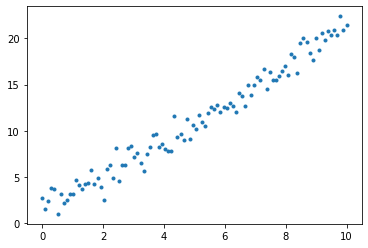

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)
x=np.linspace(0,10,100)
y=1+2*x+np.random.normal(size=100)
plt.plot(x,y,'.')

`(1)` 오차제곱합의 최소값을 활용하여 $\beta$를 추정하고자 할때 적절한 손실함수를 쓰시오. 

`(2)` 다음은 tensorflow를 활용하여 모델을 학습하는 sample code이다. 

In [2]:
import tensorflow as tf
m1 = tf.keras.models.Sequential()
m1.add(tf.keras.layers.Dense(1,input_shape=(1,),activation='linear'))
m1.compile(loss='mse')
m1.fit(x,y,epochs=100,verbose=0)

학습결과를 시각화한 것은 아래와 같다. (blue: observed data, orange: predicted line)

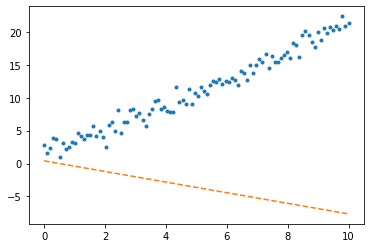

In [3]:
yhat=m1.predict(x)
plt.plot(x,y,'.')
plt.plot(x,yhat,'--')

학습한 계수값을 알기 위하여 아래를 실행하여 보고 추정된 $\hat{\beta}_0$, $\hat{\beta}_1$의 값을 쓰라. 
```python
m1.weights
```

`(3)` 학습성능을 향상시키기 위해 아래와 같은 단계로 모형을 개선하였다. 

(a) 에폭 증가
```python
modela = tf.keras.models.Sequential()
modela.add(tf.keras.layers.Dense(1,input_shape=(1,),activation='linear'))
modela.compile(loss='mse')
modela.fit(x,y,epochs=2000,verbose=0)
```

(b) 에폭 증가 + 더 깊은 신경망 
```python
modelb = tf.keras.models.Sequential()
modelb.add(tf.keras.layers.Dense(1,input_shape=(1,),activation='linear'))
modelb.add(tf.keras.layers.Dense(1,activation='linear'))
modelb.compile(loss='mse')
modelb.fit(x,y,epochs=2000,verbose=0)
```

(c) 에폭 증가 + 더 깊은 신경망 + 더 넓은 신경망 
```python
import tensorflow as tf
modelc = tf.keras.models.Sequential()
modelc.add(tf.keras.layers.Dense(20,input_shape=(1,),activation='linear'))
modelc.add(tf.keras.layers.Dense(1,input_shape=(1,),activation='linear'))
modelc.compile(loss='mse')
modelc.fit(x,y,epochs=2000,verbose=0)
```

다음중 의미있는 개선이라고 판단되는 것을 모두 고르라 

- (2) $\to$ (3)-(a) 
- (3)-(a) $\to$ (3)-(b)
- (3)-(b) $\to$ (3)-(c)

개선의 의미가 없다고 생각하는 항목은 그 이유를 서술하라. 

`(4)` 아래는 (3)-(b)의 모형으로 학습한 계수값을 나타낸것이다. 

In [4]:
modelb = tf.keras.models.Sequential()
modelb.add(tf.keras.layers.Dense(1,input_shape=(1,),activation='linear'))
modelb.add(tf.keras.layers.Dense(1,activation='linear'))
modelb.compile(loss='mse')
modelb.fit(x,y,epochs=2000,verbose=0)
modelb.weights

[<tf.Variable 'dense_1/kernel:0' shape=(1, 1) dtype=float32, numpy=array([[1.5568802]], dtype=float32)>,
 <tf.Variable 'dense_1/bias:0' shape=(1,) dtype=float32, numpy=array([0.38122213], dtype=float32)>,
 <tf.Variable 'dense_2/kernel:0' shape=(1, 1) dtype=float32, numpy=array([[1.2621937]], dtype=float32)>,
 <tf.Variable 'dense_2/bias:0' shape=(1,) dtype=float32, numpy=array([0.7481399], dtype=float32)>]

이 계수값을 바탕으로 아래식에 해당하는 적절한 $a,b$를 추론하라. 

$$\hat{y}_i= ax_i +b$$

### \# 2. (50점)

아래와 같은 자료를 관측하였다고 하자.

In [5]:
# hide
np.random.seed(0)
import pandas as pd
#x=[0]*25+[1]*25+[2]*25+[3]*25+np.random.normal(size=100,scale=0.2)
#y=[0]*25+[1]*25+[2]*25+[3]*25+np.random.normal(size=100,scale=0.2)
#z=['a']*25+['b']*25+['c']*25+['a']*25
#pd.DataFrame({'x':x,'y':y,'z':z}).to_csv("2021-06-13-data.csv",index=False)

In [6]:
import seaborn as sns
import pandas as pd
data=pd.read_csv('2021-06-12-data.csv')
data

,x,y,z
0,0.352810,0.376630,a
1,0.080031,-0.269552,a
2,0.195748,-0.254097,a
3,0.448179,0.193879,a
4,0.373512,-0.234625,a
...,...,...,...
95,3.141315,2.965691,a
96,3.002100,3.154358,a
97,3.357174,3.164701,a
98,3.025382,3.432647,a


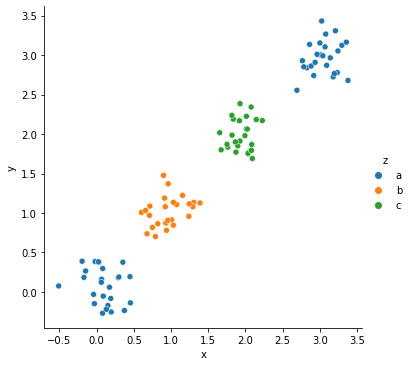

In [7]:
sns.relplot(data=data,x='x',y='y',hue='z')

`(1)` $(x,y)$의 값을 바탕으로 $z$를 추정하는 모형을 아래와 같이 설계하고자 한다. 

- 구조: 입력층 $\to$ 노드수가32개인 은닉층 $\to$ 노드수가32개인 은닉층 $\to$ 노드수가32개인 은닉층 $\to$ 출력층 
- 활성화함수: relu $\to$ relu $\to$ relu $\to$ softmax 
- loss = categorical cross entropy
- 에폭 = 200
- 미니배치크기 = 8

아래코드에서 ??를 완성하여 위의 조건에 부합하는 적절한 모형을 설계하고 `model1.predict()`를 사용한 분류결과를 제출하라. *(code와 predict함수를 사용한 분류결과 제출)*

```python
# 데이터 정리 
X=np.array([data.x,data.y]).transpose()
y=np.array([data.z])
from sklearn.preprocessing import * 
mms=MinMaxScaler()
mms.fit(X)
X=mms.transform(X)
onehot=OneHotEncoder()
onehot.fit(y.reshape(-1,1))
y=onehot.transform(y.reshape(-1,1)).toarray()
# dnn architecture 설계 
model1 = tf.keras.models.Sequential()
model1.add(tf.keras.layers.Dense(??,input_shape=??,activation='relu'))
model1.add(tf.keras.layers.Dense(??,activation=??))
model1.add(tf.keras.layers.Dense(??,activation=??))
model1.add(tf.keras.layers.Dense(??,activation='softmax'))
model1.compile(loss=??)
model1.fit(X,y,epochs=200,batch_size=??,verbose=0)
```

`(2)` 편의상 아래와 같은 층을 정의하자. 

- 0층: 입력층
- 1층: 은닉층1 (노드32)
- 2층: 은닉층2 (노드32)
- 3층: 은닉층3 (노드32) 
- 4층: 출력층 

1층의 입력값과 출력값은 아래와 같이 구할 수 있다.

In [8]:
# hide
# 데이터 정리 
X=np.array([data.x,data.y]).transpose()
y=np.array([data.z])
from sklearn.preprocessing import * 
mms=MinMaxScaler()
mms.fit(X)
X=mms.transform(X)
onehot=OneHotEncoder()
onehot.fit(y.reshape(-1,1))
y=onehot.transform(y.reshape(-1,1)).toarray()
# dnn architecture 설계 
model1 = tf.keras.models.Sequential()
model1.add(tf.keras.layers.Dense(32,input_shape=(2,),activation='relu'))
model1.add(tf.keras.layers.Dense(32,activation='relu'))
model1.add(tf.keras.layers.Dense(32,activation='relu'))
model1.add(tf.keras.layers.Dense(3,activation='softmax'))
model1.compile(loss='categorical_crossentropy')
model1.fit(X,y,epochs=200,batch_size=8,verbose=0)

1층의 입력: 

In [9]:
u1=X@model1.weights[0]+model1.weights[1]
print(u1)

tf.Tensor(
[[ 0.12024569 -0.06456085 -0.0484951  ... -0.03607533 -0.1142422
   0.67249703]
 [ 0.04808714 -0.08386813 -0.00258221 ... -0.00380046 -0.03613948
   0.60597503]
 [ 0.05914535 -0.0940557  -0.00183713 ... -0.00527499 -0.04468873
   0.62277335]
 ...
 [ 0.58777124 -0.15948065 -0.21574773 ... -0.18708983 -0.5630463
   1.2140237 ]
 [ 0.5796678  -0.10808398 -0.24229605 ... -0.1976102  -0.5682097
   1.1796457 ]
 [ 0.5718717  -0.12519704 -0.22844124 ... -0.19015498 -0.55586225
   1.1800072 ]], shape=(100, 32), dtype=float32)


1층의 출력: 

In [10]:
v1=tf.nn.relu(u1)
print(v1)

tf.Tensor(
[[0.12024569 0.         0.         ... 0.         0.         0.67249703]
 [0.04808714 0.         0.         ... 0.         0.         0.60597503]
 [0.05914535 0.         0.         ... 0.         0.         0.62277335]
 ...
 [0.58777124 0.         0.         ... 0.         0.         1.2140237 ]
 [0.5796678  0.         0.         ... 0.         0.         1.1796457 ]
 [0.5718717  0.         0.         ... 0.         0.         1.1800072 ]], shape=(100, 32), dtype=float32)


이를 활용하여 4층의 입력과 출력을 구하라. (*코드제출*)

### \# 3. (10점) 

다음문제를 잘 읽고 참과 거짓을 판단하여라. (이유는 쓰지 않아도 무방함) 

`(1)` 드롭아웃은 과적합을 방지하는 효과가 있다. 

`(2)` 경사하강법은 손실함수의 covex 유무에 관계없이 언제나 전역최소값을 찾는다. 

`(3)` 종속변수($={\bf y}$)가 독립변수($={\bf X}$)의 선형조합으로 표현가능하다면 깊은 신경망일수록 분석에 유리하다. 

`(4)` 단층퍼셉트론은 XOR문제를 해결하면서 학계의 주목을 받았다. 

`(5)` 로지스틱 회귀모형은 반드시 오차항이 정규분포를 따라야 한다. 